In [262]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

In [263]:
titolo = "Esperienza"
xlabel = "x"
ylabel = "y"

file_input = "dati.csv"
file_output1 = "regressione.txt"
file_output2 = "residui.txt"
file_output3 = "chi.txt"
grafico_output1 = "regressione.pdf"
grafico_output2 = "residui.pdf"
grafico_output3 = "chi.pdf"

### 1. Lettura

In [264]:
data = f.csv_to_dict(file_input)

incertezza_tempo = 10 * 10**(-7)
incertezza_voltaggio = 2

xdata = np.array([data["tempo"],
                  np.full_like(data["tempo"], incertezza_tempo)])
ydata = np.array([data["voltaggio"],
                  np.full_like(data["voltaggio"], incertezza_voltaggio) + 3/100 * data["voltaggio"]])

### 2. Analisi

In [280]:
def modello(par, x):
    a,b,c,d,g = par
    return a/b * np.exp(- ( x - c ) / d ) * ( 1/d * np.sin(b * (x - c ) ) + b * np.cos(b * (x - c ) ) ) + g

v0 = 45
omega = 4.68 * 10**(5)
t0 = 0.001
tau = 10**(-5)
voff = 0.01

# Copiati dalle dispense
v0 = 7
omega = 2500 * 10**(3)
t0 = 0.097 * 10**(-6)
tau = 19.06 * 10**(-6)
voff = 0.029

param_labels = ['v0','omega','t0','tau','voff']
dati_iniziali = [v0,omega,t0,tau,voff]

Regressione

In [281]:
anal = f.fit(xdata,ydata,modello,dati_iniziali,chi=False)

f.inizializza_output(file_output1)
gf.salva_analisi(anal, param_labels, file_output1)

Residui

In [282]:
f.inizializza_output(file_output2)
res = f.residui(xdata,ydata,anal[:,0],modello,file_output2,titolo)

Chi Quadro

In [283]:
f.inizializza_output(file_output3)
chi = f.chi_quadro(xdata,ydata,anal[:,0],modello,file_output3,titolo)

### 3. Grafici

Regressione

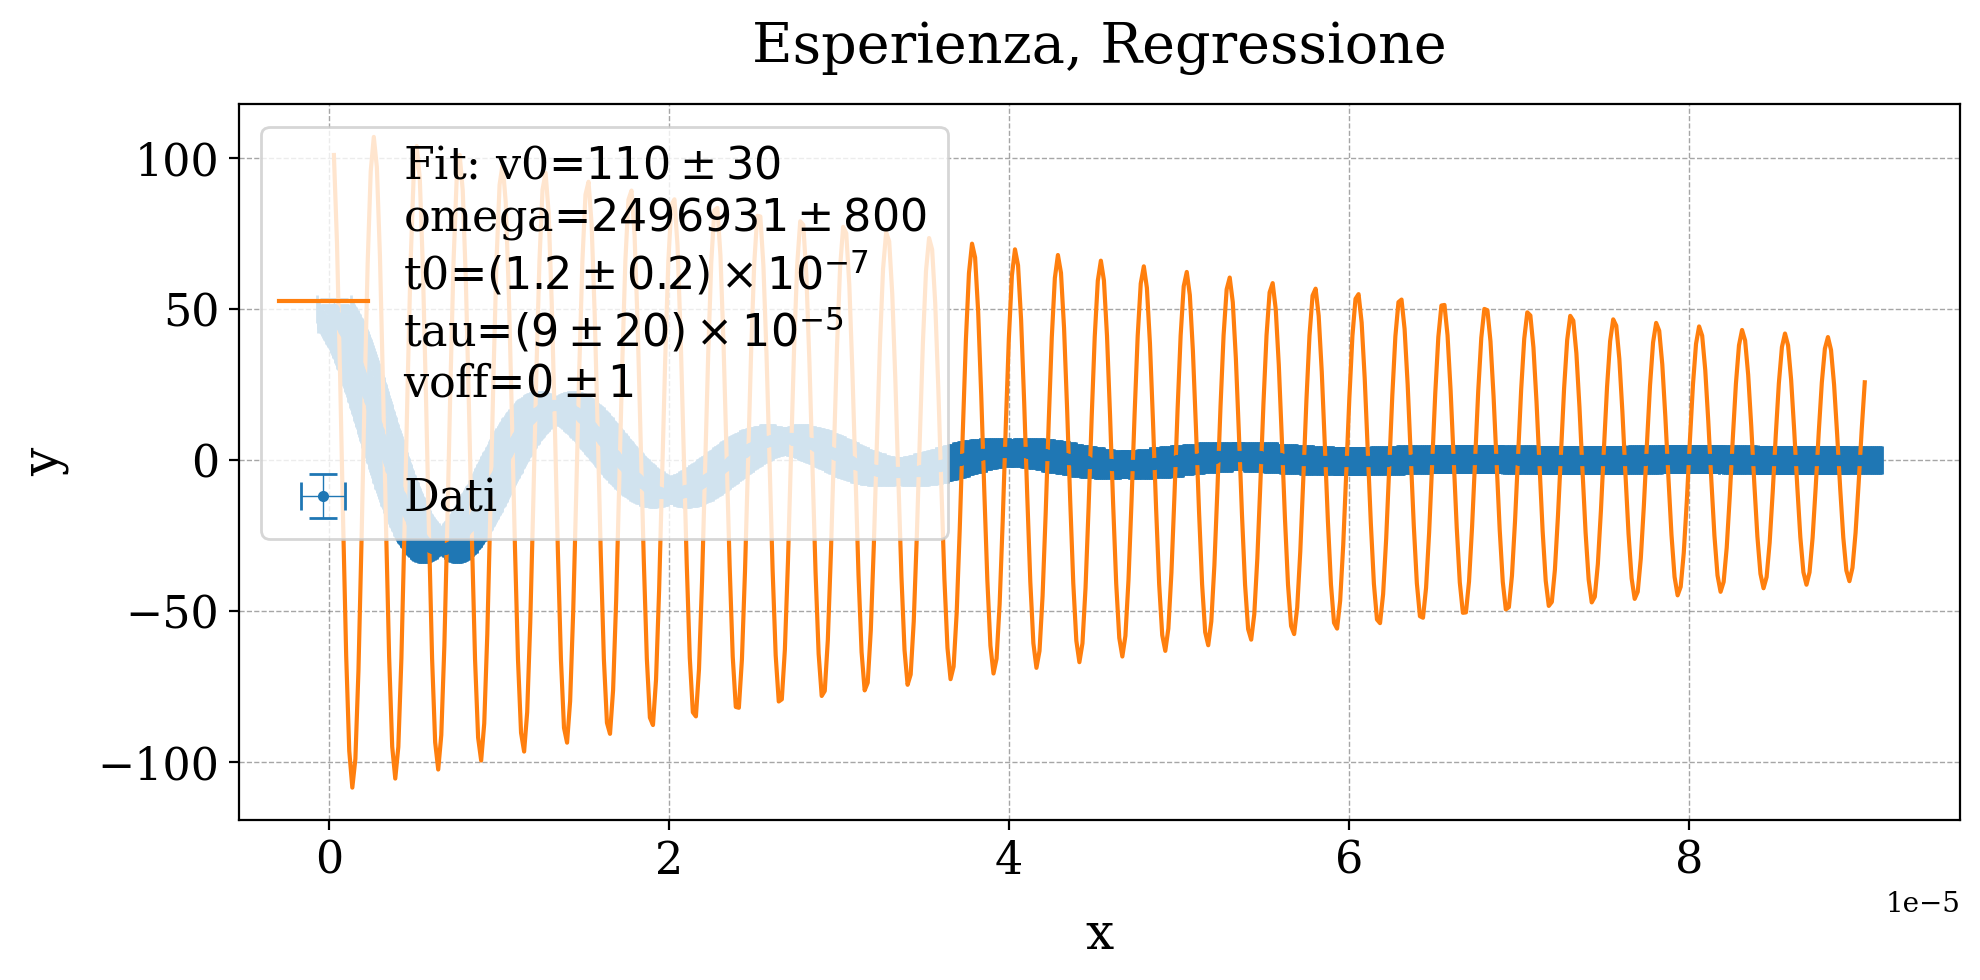

In [284]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + ", Regressione",xlabel=xlabel,ylabel=ylabel)
# Grafico dei dati con errori
ax.errorbar(xdata[0],ydata[0],xerr=xdata[1],yerr=ydata[1],
            label="Dati", **gf.errorbar_params, color = gf.colori[0])
# Grafico del fit
fit_label = "Fit: " + "".join(
    f"{param_labels[i]}={gf.formatta_errore(anal[i,0],anal[i,1])}\n" for i in range(len(param_labels))
)
x_fit = np.linspace(min(xdata[0]), max(xdata[0]), 500)
ax.plot(x_fit,modello(anal[:,0],x_fit),
        label=fit_label, **gf.plot_params, color = gf.colori[1])

ax.legend()

gf.salva_grafico(fig,grafico_output1)

Residui

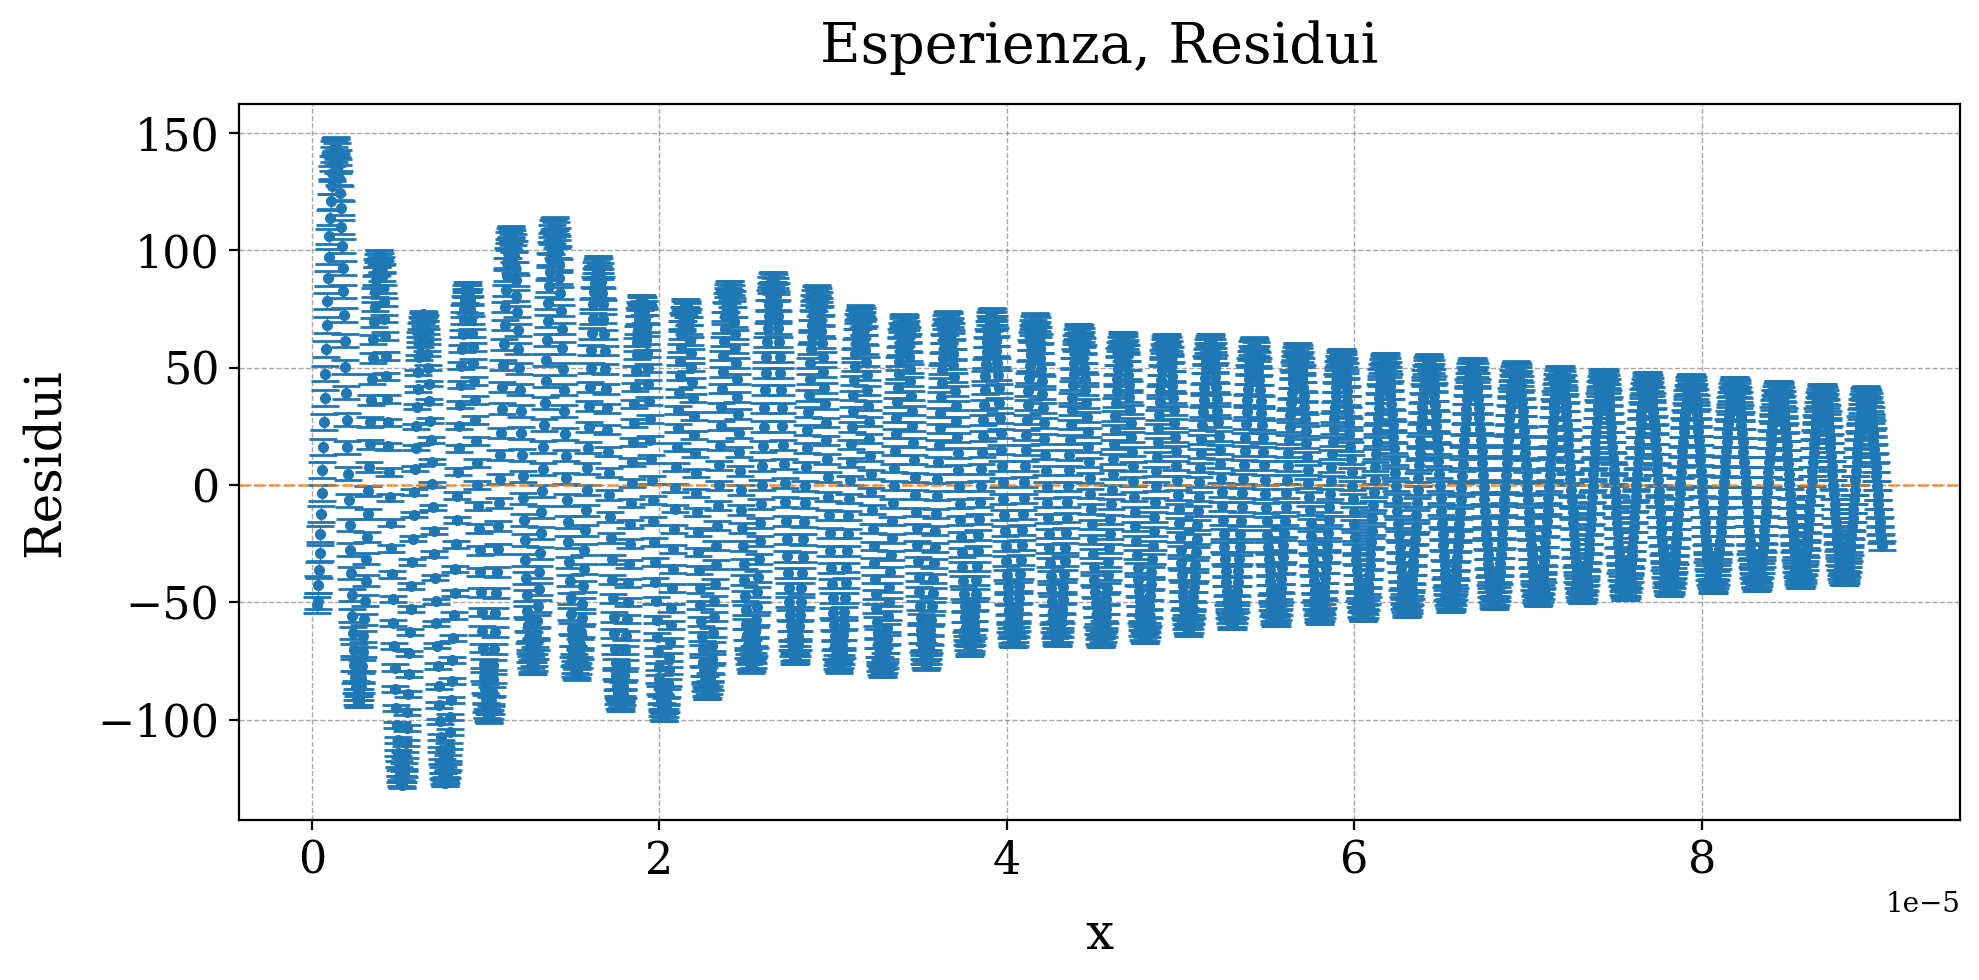

In [285]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + ", Residui",xlabel=xlabel,ylabel="Residui")

ax.errorbar(res[0],res[1],yerr=res[2],
            **gf.errorbar_params, color=gf.colori[0])
ax.axhline(0,
           **gf.line_params, color=gf.colori[1])

gf.salva_grafico(fig,grafico_output2)

Chi Quadro

<>:2: SyntaxWarning: invalid escape sequence '\c'
<>:2: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_7886/1845354324.py:2: SyntaxWarning: invalid escape sequence '\c'
  gf.parametri_grafico(ax,titolo + r", $\chi^2$",xlabel=xlabel,ylabel="$\chi^2$")


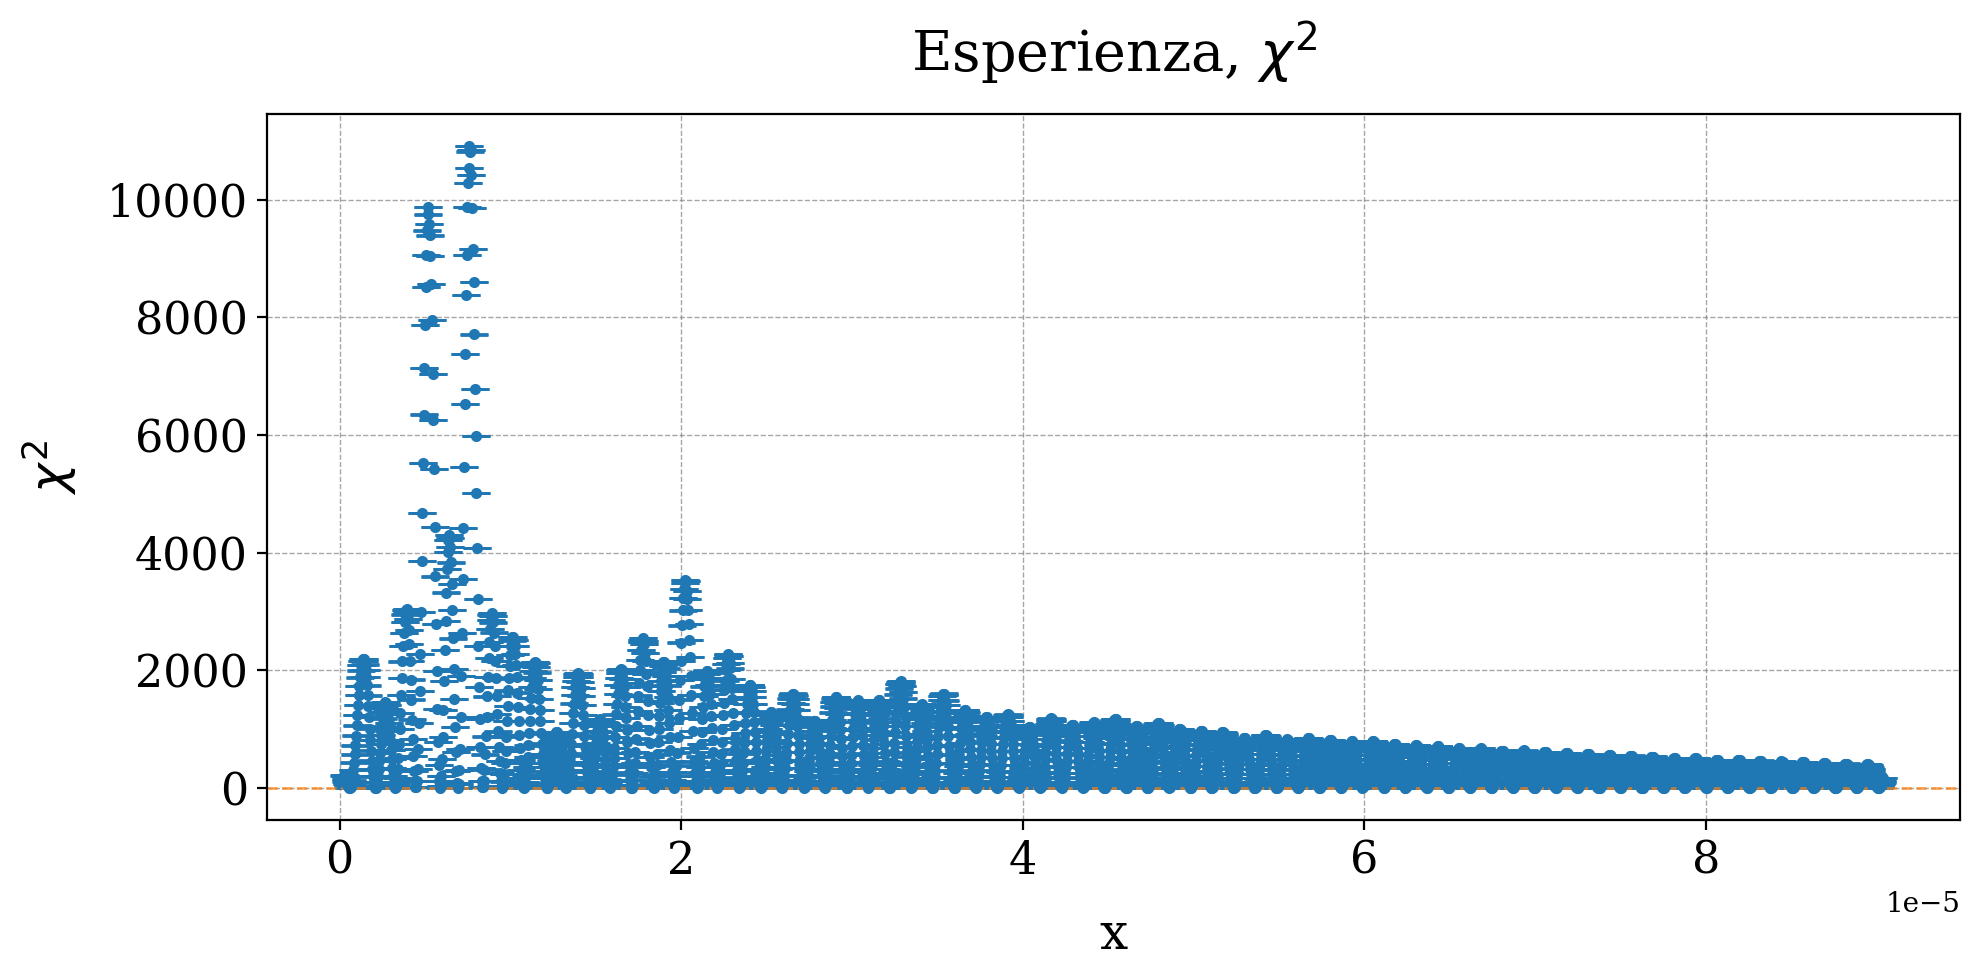

In [286]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + r", $\chi^2$",xlabel=xlabel,ylabel="$\chi^2$")

ax.errorbar(chi[0],chi[1],yerr=chi[2],
            **gf.errorbar_params, color=gf.colori[0])
ax.axhline(0,
           **gf.line_params, color=gf.colori[1])

gf.salva_grafico(fig,grafico_output3)